# EDA

## What has been done
- [1. Overview](#1.-Overview)
- [2. Data Cleaning](#2.-Data-Cleaning)
- [3. Essential Variable Analysis](#3.-Essential-Variable-Analysis)
- [4. Essential Fraud-Focused Analysis](#4.-Essential-Fraud-Focused-Analysis)
- [5. Correlations](#5.-Correlations)
- [6. Key Findings](#6.-Key-Findings)

This notebook presents a concise exploratory data analysis of the credit card fraud dataset, focusing on the most informative descriptive summaries and fraud-related patterns.


## 1. Overview

This section imports the required libraries, configures inline plotting for Jupyter, loads the dataset with a robust path check, and presents the initial structure of the data.


In [13]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.api.types import is_categorical_dtype, is_object_dtype, is_string_dtype

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 4.5)

df = pd.read_csv("credit_card_fraud_10k.csv")
TARGET = "is_fraud"

In [ ]:
def is_categorical_series(series):
    return is_categorical_dtype(series) or is_object_dtype(series) or is_string_dtype(series)


def plot_numeric_distribution(data, column, color="#4C78A8"):
    plt.figure(figsize=(8, 4.5))
    ax = sns.histplot(data[column], kde=True, color=color, edgecolor="white")
    ax.axvline(data[column].mean(), color="crimson", linestyle="--", linewidth=1.5, label=f"Mean: {data[column].mean():.2f}")
    ax.axvline(data[column].median(), color="darkgreen", linestyle=":", linewidth=1.5, label=f"Median: {data[column].median():.2f}")
    ax.set_title(f"Distribution of {column.replace('_', ' ').title()}")
    ax.set_xlabel(column.replace("_", " ").title())
    ax.set_ylabel("Count")
    ax.legend()
    plt.tight_layout()
    plt.show()


def plot_count_chart(data, column, color="#72B7B2"):
    plt.figure(figsize=(8, 4.5))
    order = data[column].value_counts().index
    ax = sns.countplot(data=data, x=column, order=order, color=color)
    ax.set_title(f"Count of {column.replace('_', ' ').title()}")
    ax.set_xlabel(column.replace("_", " ").title())
    ax.set_ylabel("Count")
    if is_categorical_series(data[column]):
        plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.show()


def plot_boxplot_by_target(data, column, color="#72B7B2"):
    plt.figure(figsize=(7, 4.5))
    sns.boxplot(data=data, x=TARGET, y=column, color=color)
    plt.title(f"{column.replace('_', ' ').title()} by Fraud Status")
    plt.xlabel("Is Fraud")
    plt.ylabel(column.replace("_", " ").title())
    plt.tight_layout()
    plt.show()


def plot_fraud_rate(data, column, color="#E45756"):
    fraud_rate = data.groupby(column, observed=False)[TARGET].mean().sort_values(ascending=False)
    plt.figure(figsize=(8, 4.5))
    ax = fraud_rate.plot(kind="bar", color=color)
    ax.set_title(f"Fraud Rate by {column.replace('_', ' ').title()}")
    ax.set_xlabel(column.replace("_", " ").title())
    ax.set_ylabel("Fraud Rate")
    if is_categorical_series(data[column]):
        plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.show()
    return fraud_rate


In [ ]:
df.head()

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   transaction_id       10000 non-null  int64   
 1   amount               10000 non-null  float64 
 2   transaction_hour     10000 non-null  int64   
 3   merchant_category    10000 non-null  category
 4   foreign_transaction  10000 non-null  int64   
 5   location_mismatch    10000 non-null  int64   
 6   device_trust_score   10000 non-null  int64   
 7   velocity_last_24h    10000 non-null  int64   
 8   cardholder_age       10000 non-null  int64   
 9   is_fraud             10000 non-null  int64   
dtypes: category(1), float64(1), int64(8)
memory usage: 713.2 KB


In [ ]:
df.describe(include="all").transpose()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
transaction_id,10000.0,NaN,NaN,NaN,5000.5,2886.89568,1.0,2500.75,5000.5,7500.25,10000.0
amount,10000.0,NaN,NaN,NaN,175.949849,175.392827,0.0,50.905,122.095,242.48,1471.04
transaction_hour,10000.0,NaN,NaN,NaN,11.5933,6.922708,0.0,6.0,12.0,18.0,23.0
merchant_category,10000,5,Food,2093,NaN,NaN,NaN,NaN,NaN,NaN,NaN
foreign_transaction,10000.0,NaN,NaN,NaN,0.0978,0.297059,0.0,0.0,0.0,0.0,1.0
location_mismatch,10000.0,NaN,NaN,NaN,0.0857,0.279935,0.0,0.0,0.0,0.0,1.0
device_trust_score,10000.0,NaN,NaN,NaN,61.7989,21.487053,25.0,43.0,62.0,80.0,99.0
velocity_last_24h,10000.0,NaN,NaN,NaN,2.0089,1.432559,0.0,1.0,2.0,3.0,9.0
cardholder_age,10000.0,NaN,NaN,NaN,43.4687,14.979147,18.0,30.0,44.0,56.0,69.0
is_fraud,10000.0,NaN,NaN,NaN,0.0151,0.121957,0.0,0.0,0.0,0.0,1.0


The dataset contains transaction-level information with a binary fraud label. It combines numeric behavioral indicators, binary risk flags, and one business category variable, which makes it suitable for a compact fraud-focused EDA.


## 2. Data Cleaning

This section checks the main quality issues relevant for exploratory analysis: missing values, duplicated rows, and categorical consistency.


In [9]:
missing_values = df.isna().sum().to_frame("missing_values")
duplicate_rows = df.duplicated().sum()
merchant_categories = sorted(df["merchant_category"].dropna().unique().tolist())

print(f"Duplicate rows: {duplicate_rows}")
print(f"Merchant categories: {merchant_categories}")
missing_values

Duplicate rows: 0
Merchant categories: ['Clothing', 'Electronics', 'Food', 'Grocery', 'Travel']


,missing_values
transaction_id,0
amount,0
transaction_hour,0
merchant_category,0
foreign_transaction,0
location_mismatch,0
device_trust_score,0
velocity_last_24h,0
cardholder_age,0
is_fraud,0


`transaction_id` is treated only as an identifier and is excluded from analytical interpretation. Based on these checks, the dataset is already clean enough for exploratory analysis and does not require major preprocessing at this stage.


## 3. Essential Variable Analysis

This section keeps only the most informative standalone variable plots for a concise report-style notebook.


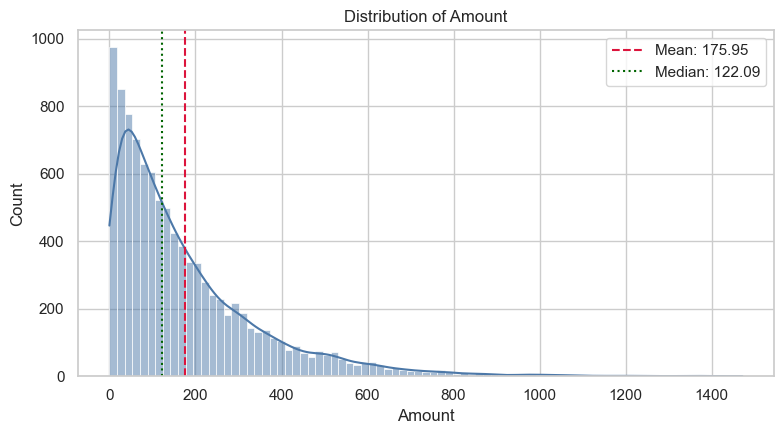

In [10]:
plot_numeric_distribution(df, "amount")


`amount` is positively skewed, with most transactions concentrated at lower values and a smaller number of higher-value purchases. The gap between mean and median confirms the right-tailed distribution.


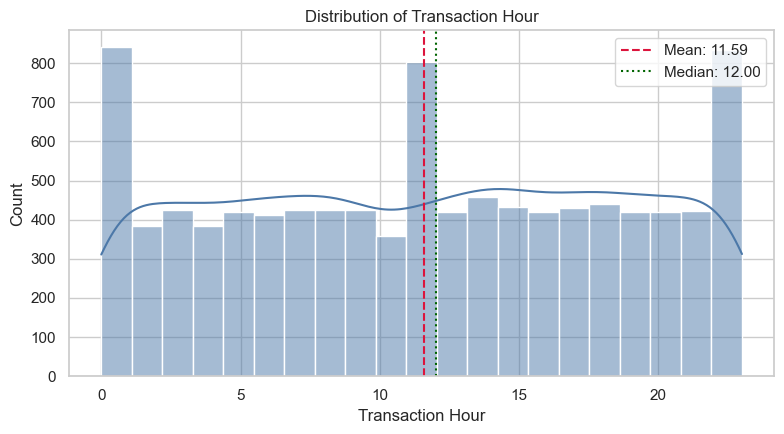

In [11]:
plot_numeric_distribution(df, "transaction_hour")


`transaction_hour` shows when activity occurs across the day. This variable is relevant because fraud patterns can be sensitive to unusual transaction timing.


C:\Users\madda\AppData\Local\Temp\ipykernel_31420\3070557271.py:2: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return is_categorical_dtype(series) or is_object_dtype(series) or is_string_dtype(series)


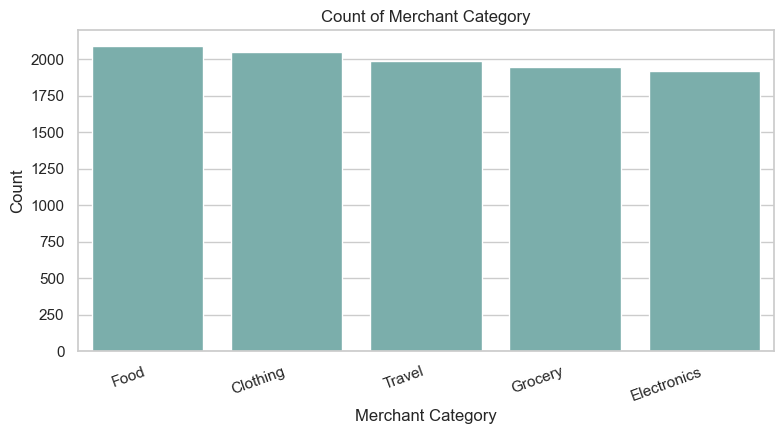

In [14]:
plot_count_chart(df, "merchant_category")

`merchant_category` is handled as a categorical variable. The frequency distribution provides useful business context before looking at category-specific fraud rates.


C:\Users\madda\AppData\Local\Temp\ipykernel_31420\3070557271.py:2: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return is_categorical_dtype(series) or is_object_dtype(series) or is_string_dtype(series)


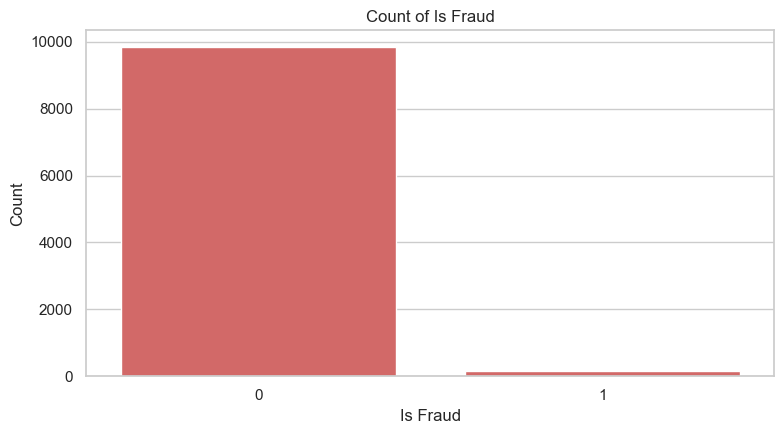

,count,percentage %
is_fraud,,
0,9849,98.49
1,151,1.51


In [16]:
plot_count_chart(df, "is_fraud", color="#E45756")

counts = df["is_fraud"].value_counts().rename("count")
pct = (df["is_fraud"].value_counts(normalize=True) * 100).round(2).rename("percentage %")
pd.concat([counts, pct], axis=1)


The target distribution is strongly imbalanced, with fraud representing only a small share of transactions. This is typical in fraud detection and should guide interpretation of later results.


## 4. Essential Fraud-Focused Analysis

The following plots focus on the variables that are most useful for understanding differences between fraudulent and legitimate transactions.


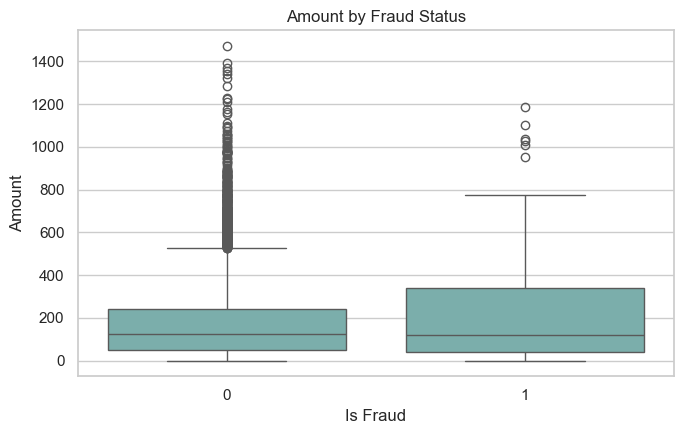

In [17]:
plot_boxplot_by_target(df, "amount")


Fraudulent transactions tend to have a somewhat higher amount on average, although the overlap between the two classes remains substantial. This suggests that amount is informative but not sufficient on its own.


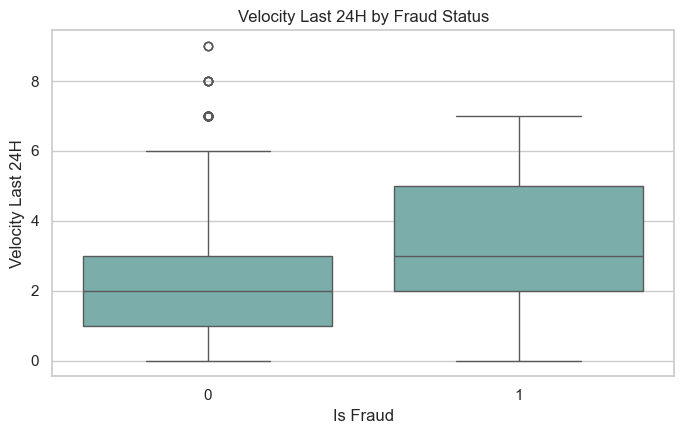

In [18]:
plot_boxplot_by_target(df, "velocity_last_24h")


Fraudulent transactions generally show higher recent transaction velocity. This supports the idea that bursts of activity in a short period are a meaningful fraud signal.


C:\Users\madda\AppData\Local\Temp\ipykernel_31420\3070557271.py:2: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return is_categorical_dtype(series) or is_object_dtype(series) or is_string_dtype(series)


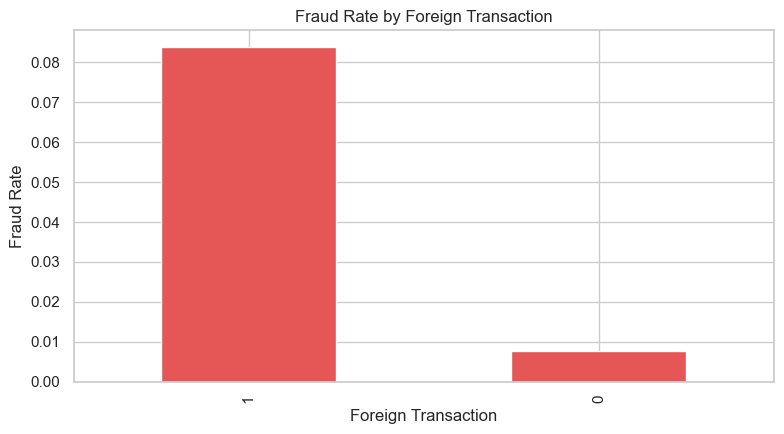

foreign_transaction
1    0.083845
0    0.007648
Name: is_fraud, dtype: float64

In [19]:
plot_fraud_rate(df, "foreign_transaction")


Foreign transactions exhibit a substantially higher fraud rate than domestic transactions. This makes cross-border activity one of the clearest risk indicators in the dataset.


C:\Users\madda\AppData\Local\Temp\ipykernel_31420\3070557271.py:2: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return is_categorical_dtype(series) or is_object_dtype(series) or is_string_dtype(series)


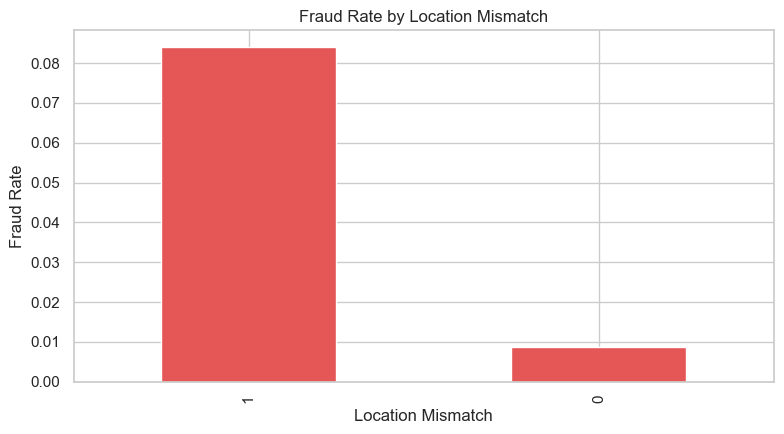

location_mismatch
1    0.084014
0    0.008640
Name: is_fraud, dtype: float64

In [20]:
plot_fraud_rate(df, "location_mismatch")


A location mismatch is also associated with a markedly higher fraud rate. Geographic inconsistency therefore appears to be a strong anomaly flag.


C:\Users\madda\AppData\Local\Temp\ipykernel_31420\3070557271.py:2: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return is_categorical_dtype(series) or is_object_dtype(series) or is_string_dtype(series)


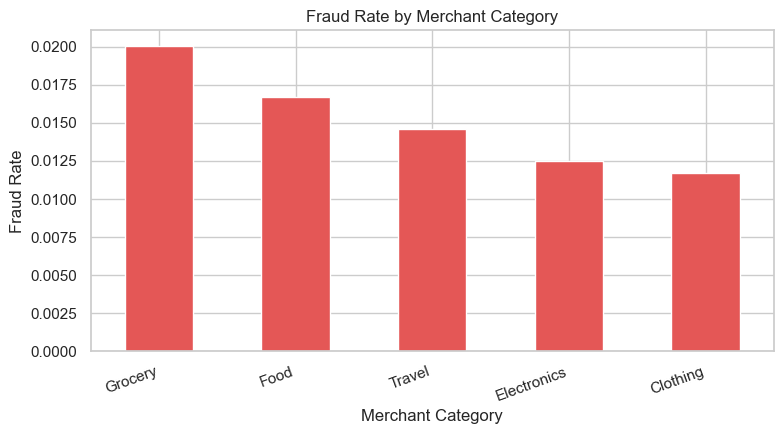

merchant_category
Grocery        0.020062
Food           0.016722
Travel         0.014573
Electronics    0.012480
Clothing       0.011707
Name: is_fraud, dtype: float64

In [21]:
plot_fraud_rate(df, "merchant_category")


Fraud rates vary across merchant categories, which indicates that transaction context matters. Some business areas appear more exposed than others even when raw transaction counts differ.


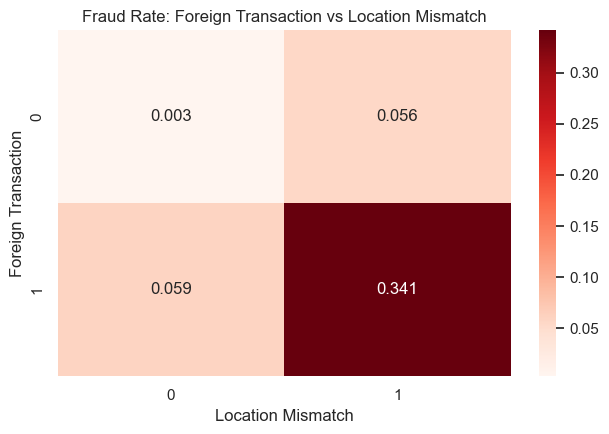

In [22]:
interaction = df.groupby(["foreign_transaction", "location_mismatch"], observed=False)[TARGET].mean().unstack()

plt.figure(figsize=(6.5, 4.5))
sns.heatmap(interaction, annot=True, fmt=".3f", cmap="Reds")
plt.title("Fraud Rate: Foreign Transaction vs Location Mismatch")
plt.xlabel("Location Mismatch")
plt.ylabel("Foreign Transaction")
plt.tight_layout()
plt.show()


The combined presence of `foreign_transaction` and `location_mismatch` produces the highest fraud rate. This suggests a compounding effect in which multiple risk flags are far more informative together than separately.


## 5. Correlations

The correlation matrix below uses only numeric columns and explicitly excludes the identifier field. Categorical text variables are not passed to `.corr()`.


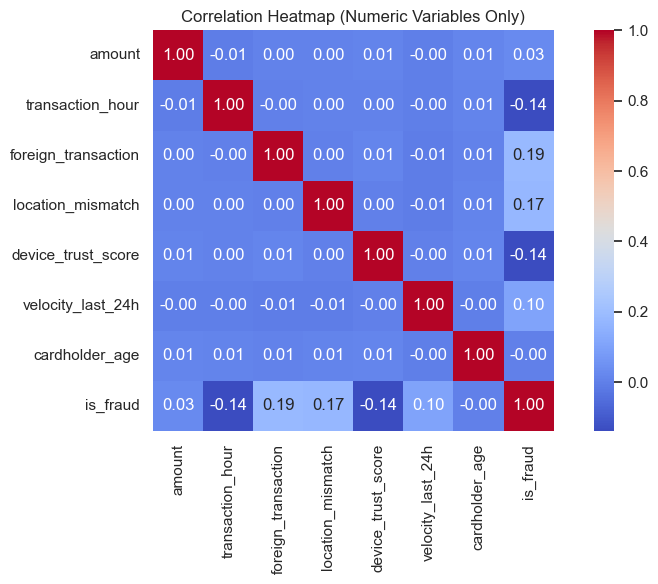

In [23]:
corr_df = df.select_dtypes(include="number").drop(columns=[ID_COL], errors="ignore")

plt.figure(figsize=(9, 6))
sns.heatmap(corr_df.corr(), annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.title("Correlation Heatmap (Numeric Variables Only)")
plt.tight_layout()
plt.show()


The strongest linear relationships with `is_fraud` are associated with `foreign_transaction`, `location_mismatch`, `transaction_hour`, and `velocity_last_24h`. The correlations are moderate, which is consistent with fraud problems where risk often arises from a combination of signals rather than a single dominant variable.


## 6. Key Findings

- The dataset is already clean enough for exploratory analysis, with `transaction_id` serving only as an identifier.
- Fraud is rare, so the target is strongly imbalanced.
- Transaction amount is right-skewed, and fraudulent transactions tend to be somewhat larger on average.
- Higher `velocity_last_24h`, foreign activity, and location mismatch are all associated with increased fraud risk.
- The combination of foreign activity and location mismatch is especially strong, indicating an interaction effect worth retaining for later modeling.
- Category-level differences in fraud rate suggest that merchant context also contributes useful information.
